# A Look at the ISLES 2018 Challenge Dataset
(Thanks to Dr. Soren Christensen for providing the Data)

In [2]:
import nibabel as nib
import numpy as np
from preprocessing import *
import os
dataset_path = os.path.expanduser('~/Desktop/ISLES_Train')

In [3]:
os.listdir(os.path.join(dataset_path, "case_1"))

['.DS_Store',
 'SMIR.Brain.XX.O.OT.345566',
 'SMIR.Brain.XX.O.CT.345562',
 'SMIR.Brain.XX.O.CT_4DPWI.345561',
 'SMIR.Brain.XX.O.CT_MTT.345565',
 'SMIR.Brain.XX.O.CT_CBF.345563',
 'SMIR.Brain.XX.O.CT_CBV.345564',
 'SMIR.Brain.XX.O.CT_Tmax.345567']

In [4]:
case_1 = nib.load(os.path.join(dataset_path, "case_1/SMIR.Brain.XX.O.CT_4DPWI.345561/SMIR.Brain.XX.O.CT_4DPWI.345561.nii"))

In [5]:
scan = case_1.get_fdata()
scan.dtype, scan.shape

(dtype('float64'), (256, 256, 8, 49))

In [6]:
scan = scan.transpose((3, 2, 0, 1))

In [7]:
from visualization import render_volume_slices

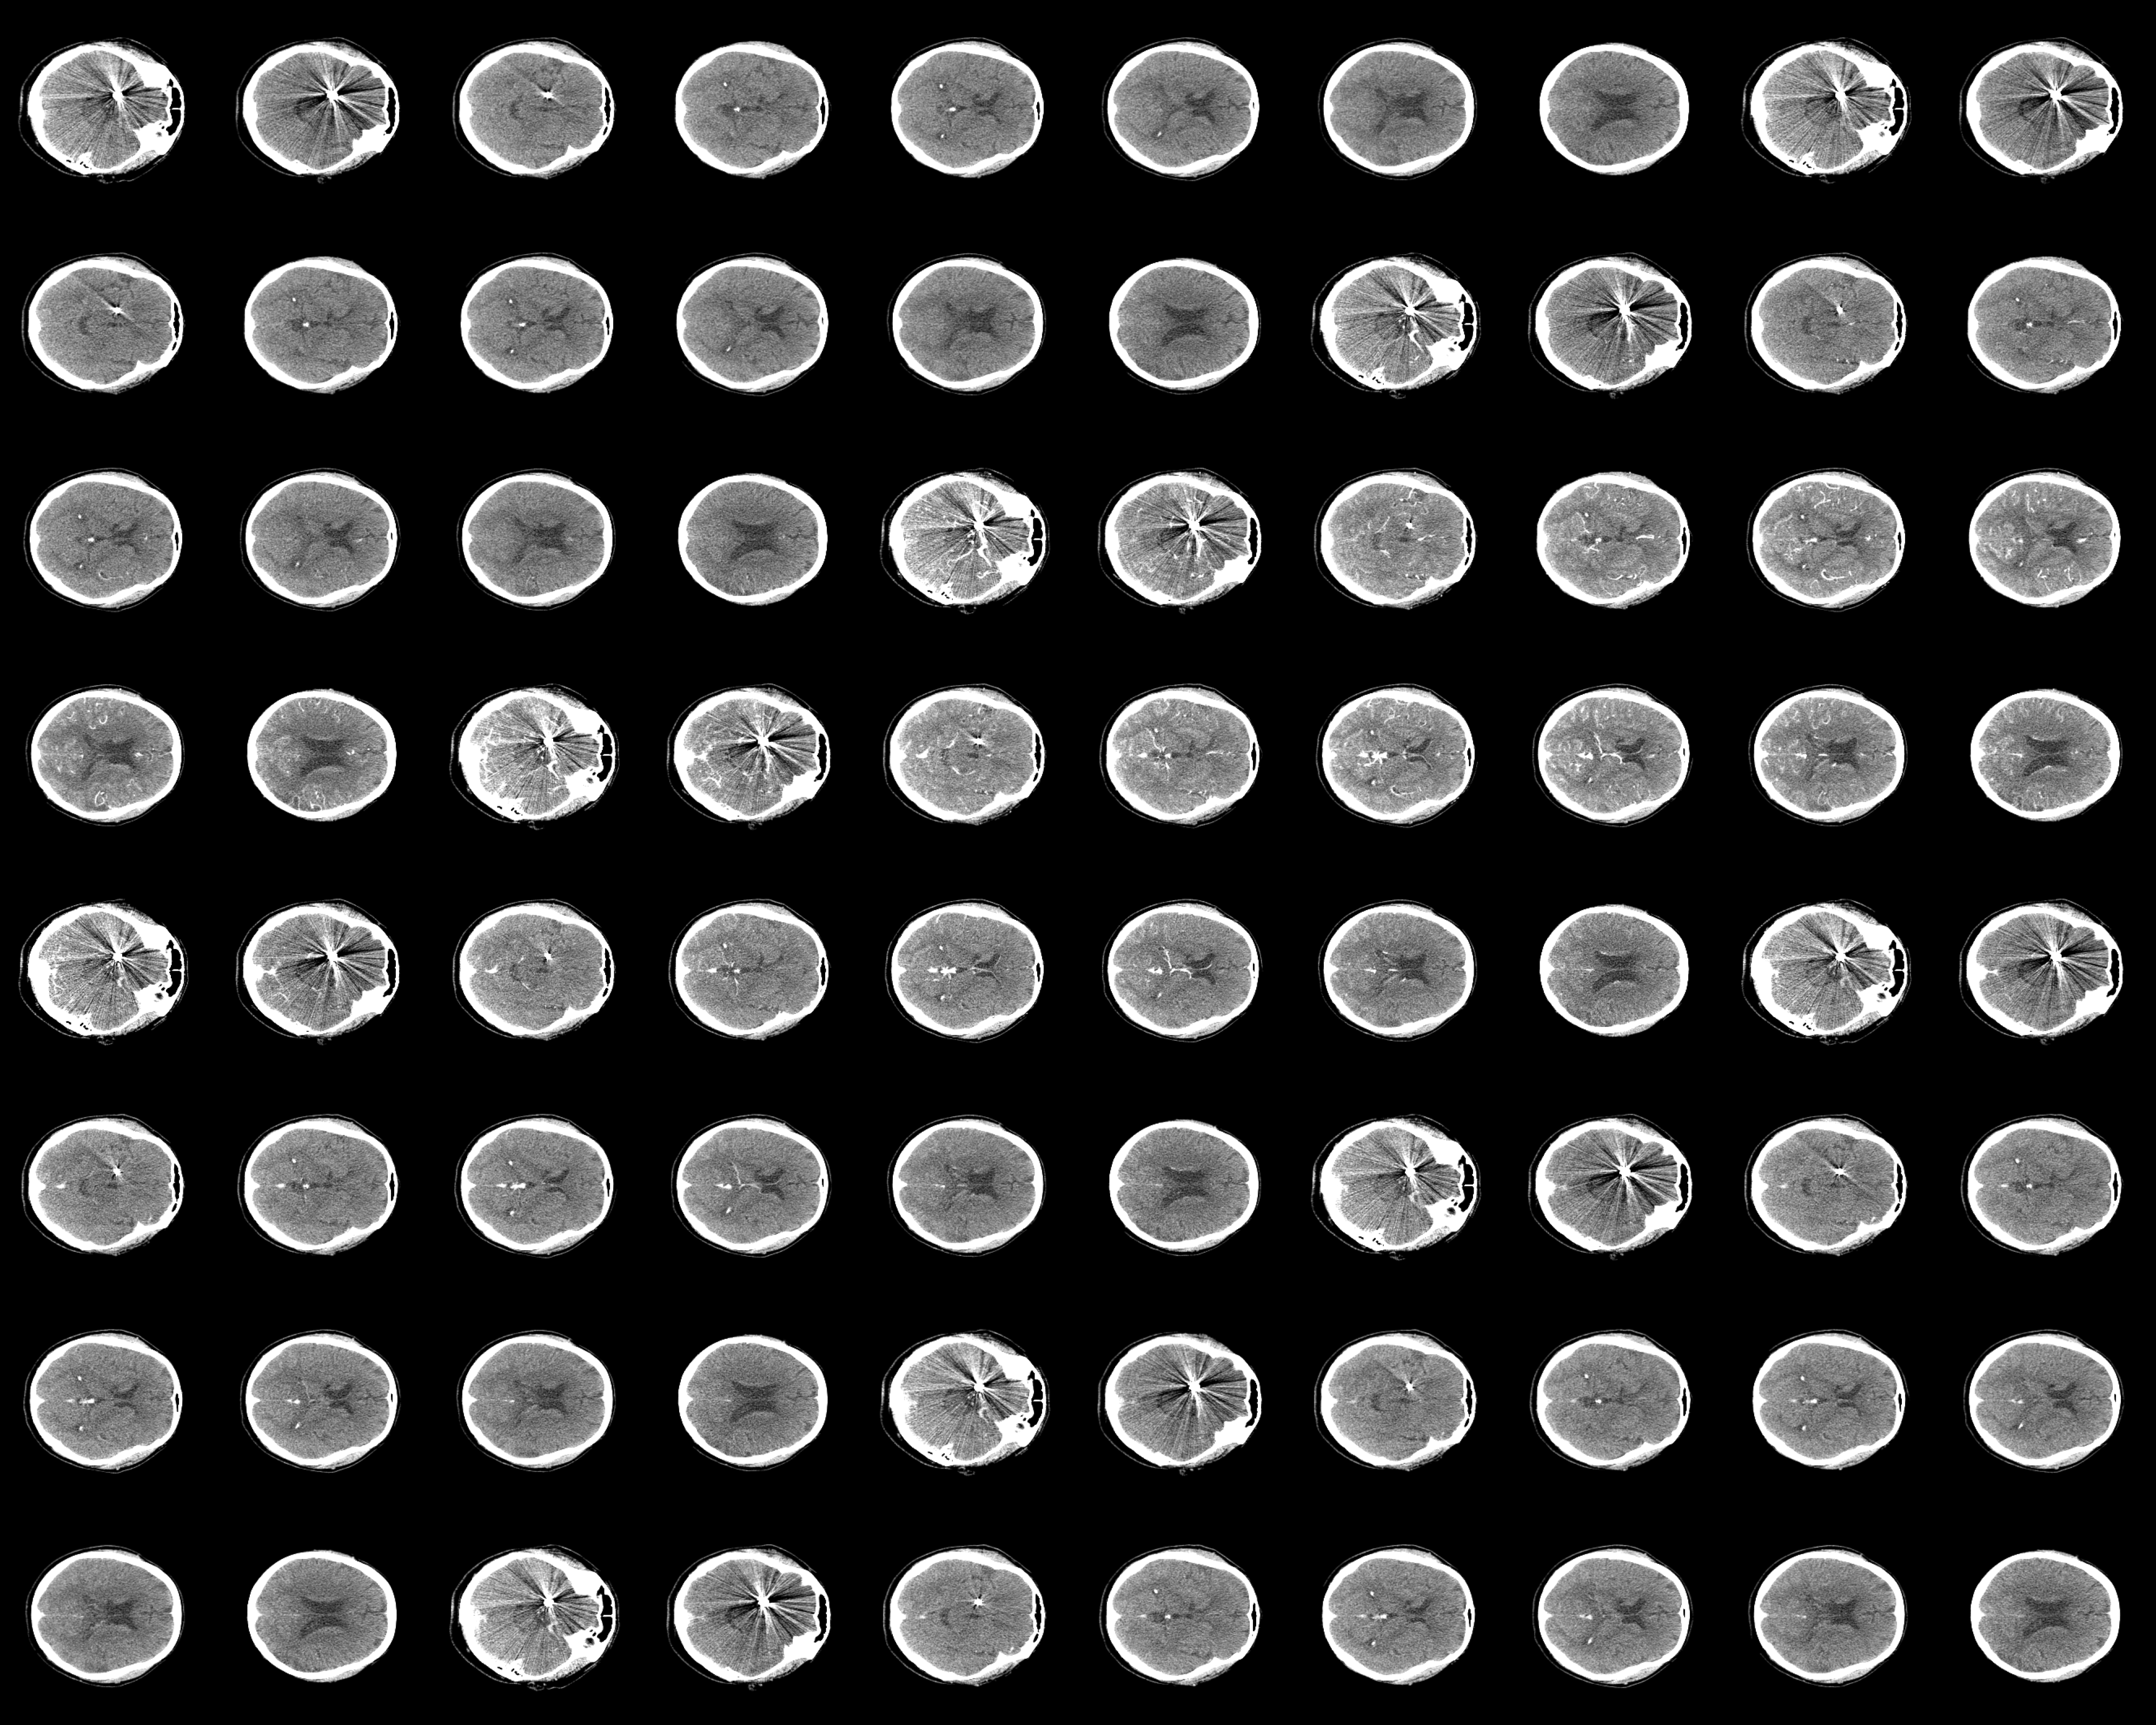

(<Figure size 4000x3200 with 80 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=ob

In [8]:
render_volume_slices(apply_window(scan[::5].reshape((-1, 256, 256)), 0, 200))

Let's look at conversion slope and intercept

In [9]:
hdr = case_1.header
print(hdr)

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b''
dim_info        : 0
dim             : [  4 256 256   8  49   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [-1.        0.976562  0.976562  5.0003    1.        1.        1.
  1.      ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 0
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b''
aux_file        : b''
qform_code      : unknown
sform_code      : aligned
quatern_b       : 0.0
quatern_c       : 0.0
quatern_d       : 0.0
qoffset_x       : 0.0
qoffset_y       : 0.0
qoffset_z       : 0.0
srow

In [10]:
num_slices = []
ts = []

# For each case
for case in os.listdir(dataset_path):
    dir_path = os.path.join(dataset_path, case)
    if not os.path.isdir(dir_path):
        continue
    
    # For each file of the case (See case content from before)
    for data_repo in os.listdir(dir_path):
        # Select the CTP folder and read in the data
        if data_repo.split('.')[-2] == 'CT_4DPWI':
            path = os.path.join(dir_path, data_repo, data_repo + '.nii')
            nii = nib.load(path)
            hdr = nii.header
            dims = hdr.get('dim')
            print('CTP:', case, dims)
            num_slices.append(dims[3])
            ts.append(dims[4])
            
        elif data_repo.split('.')[-2] == 'CT':
            path = os.path.join(dir_path, data_repo, data_repo + '.nii')
            nii = nib.load(path)
            hdr = nii.header
            dims = hdr.get('dim')
            print('CT:', case, dims)


CT: case_56 [  3 256 256   2   1   1   1   1]
CTP: case_56 [  4 256 256   2  43   1   1   1]
CT: case_69 [  3 256 256   2   1   1   1   1]
CTP: case_69 [  4 256 256   2  46   1   1   1]
CTP: case_51 [  4 256 256   2  46   1   1   1]
CT: case_51 [  3 256 256   2   1   1   1   1]
CT: case_93 [  3 256 256  16   1   1   1   1]
CTP: case_93 [  4 256 256  16  64   1   1   1]
CT: case_67 [  3 256 256   2   1   1   1   1]
CTP: case_67 [  4 256 256   2  46   1   1   1]
CTP: case_58 [  4 256 256   2  46   1   1   1]
CT: case_58 [  3 256 256   2   1   1   1   1]
CTP: case_60 [  4 256 256   2  46   1   1   1]
CT: case_60 [  3 256 256   2   1   1   1   1]
CTP: case_94 [  4 256 256  16  64   1   1   1]
CT: case_94 [  3 256 256  16   1   1   1   1]
CT: case_34 [  3 256 256   2   1   1   1   1]
CTP: case_34 [  4 256 256   2  43   1   1   1]
CT: case_33 [  3 256 256   4   1   1   1   1]
CTP: case_33 [  4 256 256   4  43   1   1   1]
CT: case_61 [  3 256 256   2   1   1   1   1]
CTP: case_61 [  4 256 25

Cts are probably a sample from the CTP scans
### Let's Look at the slice numbers

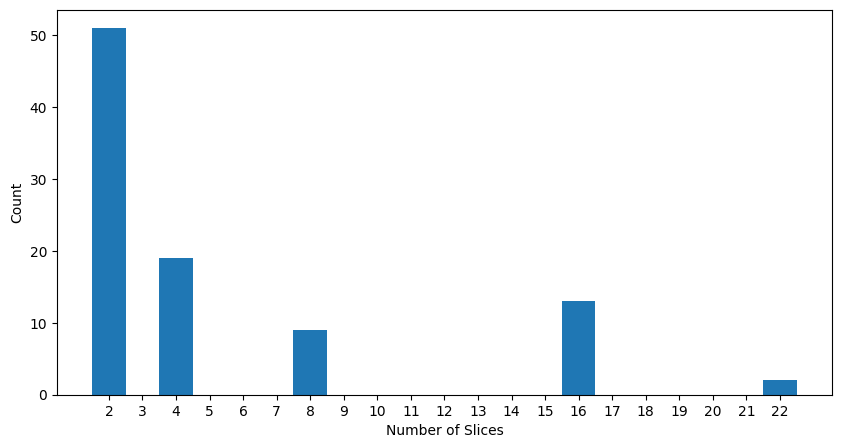

In [11]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10, 5))
plt.hist(num_slices, bins=range(min(num_slices), max(num_slices) + 2), align='left')
plt.xticks(range(min(num_slices), max(num_slices) + 1))
plt.xlabel('Number of Slices')
plt.ylabel('Count')
plt.show()

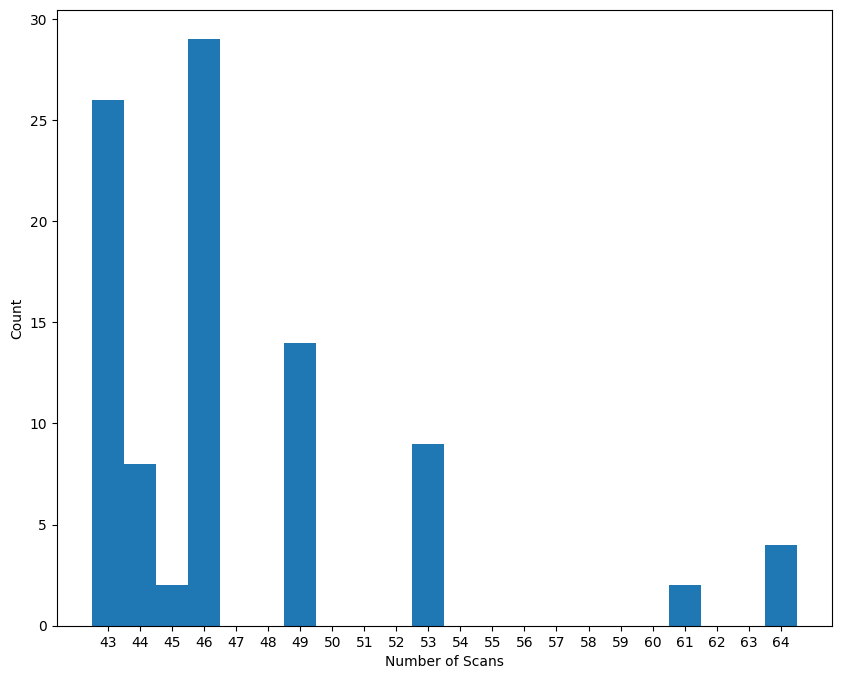

In [12]:
fig = plt.figure(figsize=(10, 8))
plt.hist(ts, bins=range(min(ts), max(ts) + 2), align='left')
plt.xticks(range(min(ts), max(ts) + 1))
plt.xlabel('Number of Scans')
plt.ylabel('Count')
plt.show()

The number of slices is heterogenous and dramatically different to the UniToBrain Dataset

But we could work with the slice_num = 16 | 22 subset.
### so let's look at the ts of scans with slice number = 16 and 22

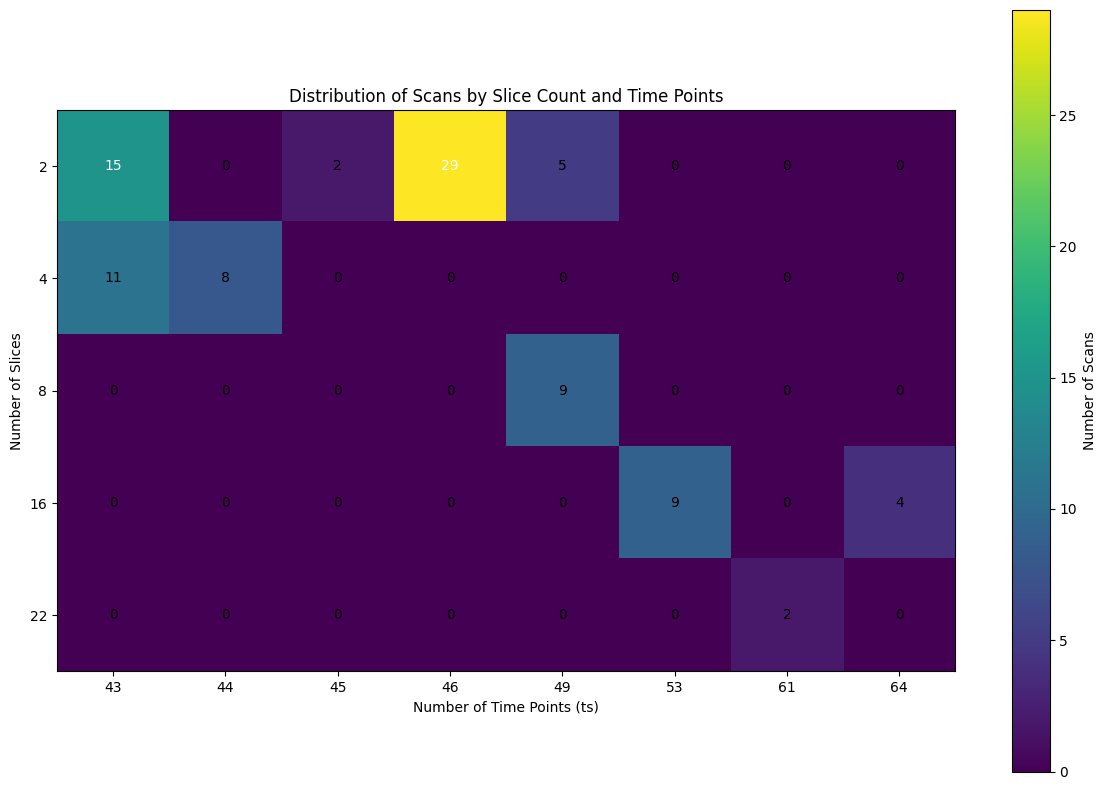

In [13]:
def plot_slice_ts_table(num_slices, ts):

    unique_slices = sorted(set(num_slices))
    unique_ts = sorted(set(ts))

    counts = np.zeros((len(unique_slices), len(unique_ts)), dtype=int)

    for s, t in zip(num_slices, ts):
        i = unique_slices.index(s)
        j = unique_ts.index(t)
        counts[i, j] += 1

    fig, ax = plt.figure(figsize=(12, 8)), plt.subplot()
    im = ax.imshow(counts, cmap='viridis')

    ax.set_xticks(np.arange(len(unique_ts)))
    ax.set_yticks(np.arange(len(unique_slices)))
    ax.set_xticklabels(unique_ts)
    ax.set_yticklabels(unique_slices)

    ax.set_xlabel('Number of Time Points (ts)')
    ax.set_ylabel('Number of Slices')
    ax.set_title('Distribution of Scans by Slice Count and Time Points')

    # Add text annotations in each cell
    for i in range(len(unique_slices)):
        for j in range(len(unique_ts)):
            text = ax.text(j, i, counts[i, j],
                        ha="center", va="center", color="w" if counts[i, j] > counts.max()/2 else "black")
            
    cbar = plt.colorbar(im)
    cbar.set_label('Number of Scans')

    plt.tight_layout()
    plt.show()

plot_slice_ts_table(num_slices, ts)

## Let's look at the ISLES Test Dataset

In [14]:
test_path = os.path.expanduser('~/Desktop/ISLES_TEST')

In [15]:
test_num_slices = []
test_ts = []

# For each case
for case in os.listdir(test_path):
    dir_path = os.path.join(test_path, case)
    if not os.path.isdir(dir_path):
        continue
    
    # For each file of the case (See case content from before)
    for data_repo in os.listdir(dir_path):
        # Select the CTP folder and read in the data
        if data_repo.split('.')[-2] == 'CT_4DPWI':
            path = os.path.join(dir_path, data_repo, data_repo + '.nii')
            nii = nib.load(path)
            hdr = nii.header
            dims = hdr.get('dim')
            print('CTP:', case, dims)
            test_num_slices.append(dims[3])
            test_ts.append(dims[4])
            
        elif data_repo.split('.')[-2] == 'CT':
            path = os.path.join(dir_path, data_repo, data_repo + '.nii')
            nii = nib.load(path)
            hdr = nii.header
            dims = hdr.get('dim')
            print('CT:', case, dims)



CT: case_56 [  3 256 256   4   1   1   1   1]
CTP: case_56 [  4 256 256   4  43   1   1   1]
CT: case_51 [  3 256 256  16   1   1   1   1]
CTP: case_51 [  4 256 256  16  53   1   1   1]
CTP: case_58 [  4 256 256   2  43   1   1   1]
CT: case_58 [  3 256 256   2   1   1   1   1]
CTP: case_60 [  4 256 256   2  43   1   1   1]
CT: case_60 [  3 256 256   2   1   1   1   1]
CT: case_34 [  3 256 256   2   1   1   1   1]
CTP: case_34 [  4 256 256   2  45   1   1   1]
CT: case_33 [  3 256 256   2   1   1   1   1]
CTP: case_33 [  4 256 256   2  45   1   1   1]
CTP: case_61 [  4 256 256   2  43   1   1   1]
CT: case_61 [  3 256 256   2   1   1   1   1]
CTP: case_59 [  4 256 256   2  43   1   1   1]
CT: case_59 [  3 256 256   2   1   1   1   1]
CT: case_50 [  3 256 256  16   1   1   1   1]
CTP: case_50 [  4 256 256  16  53   1   1   1]
CTP: case_57 [  4 256 256   4  43   1   1   1]
CT: case_57 [  3 256 256   4   1   1   1   1]
CTP: case_32 [  4 256 256   2  46   1   1   1]
CT: case_32 [  3 256 25

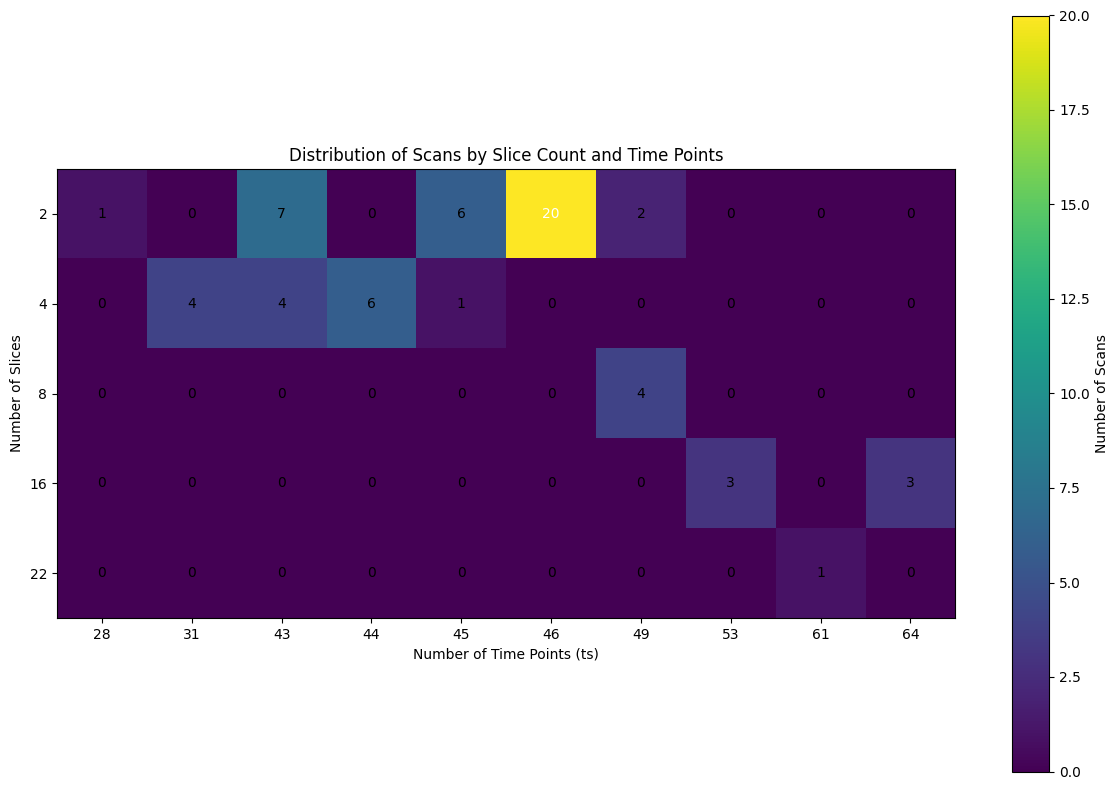

In [16]:
plot_slice_ts_table(test_num_slices, test_ts)

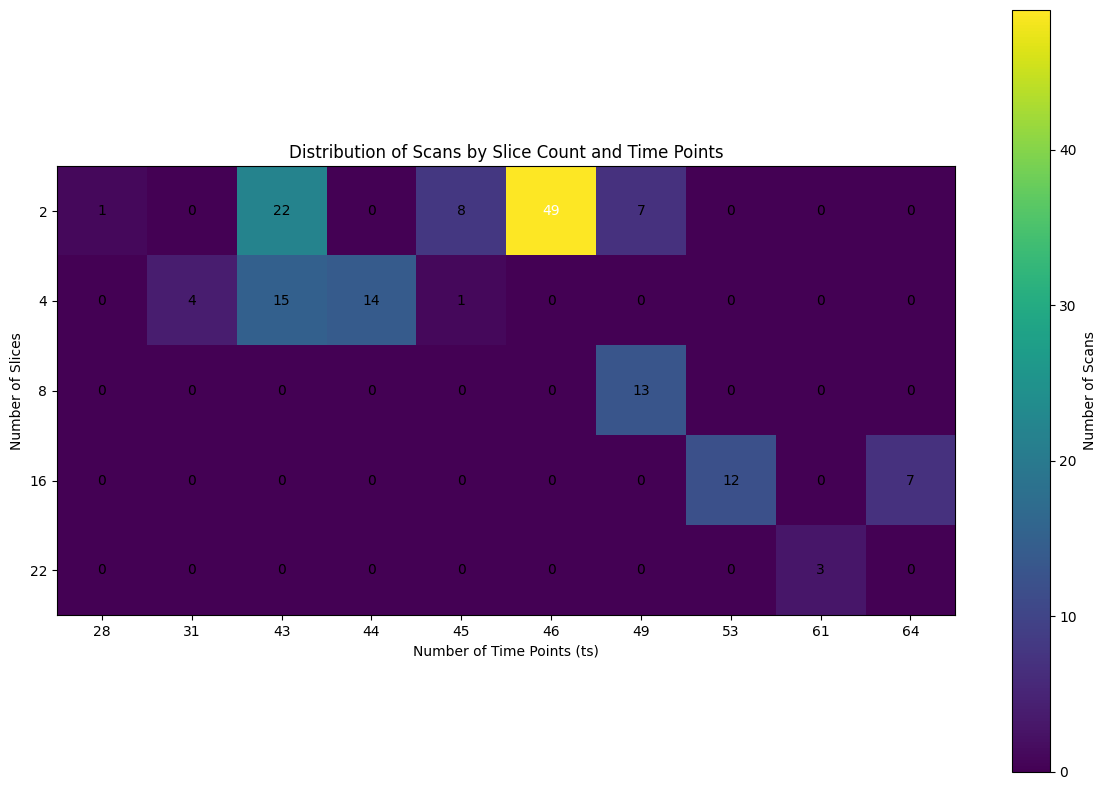

In [17]:
plot_slice_ts_table(num_slices + test_num_slices, ts + test_ts)

## Let's preprocess the Nifti Data using methods from the preprocessing package

In [18]:
from ipywidgets import IntSlider, interact
def multi_vol_seq_interactive(volume_seqs, titles=None):
    """
    Interactive plot of multiple volume sequences using ipywidgets
    
    Parameters:
    - volume_seqs: List of 4D volume sequences to display
    - titles: Optional list of titles for each sequence
    """
    print(len(volume_seqs))
    if titles is None:
        titles = [f"Volume {i+1}" for i in range(len(volume_seqs))]
        
    num_volumes = len(volume_seqs)
    nrows = int(num_volumes ** 0.5)
    ncols = (num_volumes + nrows - 1) // nrows
    
    # Calculate global min/max for consistent scaling
    global_min = min(np.min(vol) for vol in volume_seqs)
    global_max = max(np.max(vol) for vol in volume_seqs)
    
    def plot_volumes(time_idx, slice_idx):
        fig, axes = plt.subplots(nrows, ncols, 
                                figsize=(5*ncols, 5*nrows),
                                squeeze=True)
        if nrows == 1:
            if ncols == 1:
                axes = [[axes]]
            else:
                axes = [axes]
                
        for i, (volume_seq, title) in enumerate(zip(volume_seqs, titles)):
            row, col = i // ncols, i % ncols
            ax = axes[row][col]
            
            t = min(time_idx, len(volume_seq) - 1)
            s = min(slice_idx, len(volume_seq[t]) - 1)
            
            im = ax.imshow(volume_seq[t][s], cmap='magma', 
                          vmin=global_min, vmax=global_max)
            ax.set_title(title)
            plt.colorbar(im, ax=ax)
            
        plt.tight_layout()
        plt.show(block=True)
        
    max_time = max(len(vol) for vol in volume_seqs) - 1
    max_slice = max(len(vol[0]) for vol in volume_seqs) - 1
    
    interact(
        plot_volumes,
        time_idx=IntSlider(min=0, max=max_time, step=1, value=0, description='Time:'),
        slice_idx=IntSlider(min=0, max=max_slice, step=1, value=0, description='Slice:')
    )


In [19]:
# Imported above already
# from preprocessing import *

selected_paths = []
paths_16 = []
paths_22 = []
for dataset in (dataset_path, test_path):
    for case in os.listdir(dataset):
        dir_path = os.path.join(dataset, case)
        if not os.path.isdir(dir_path):
            continue
        
        for data_repo in os.listdir(dir_path):
            if not data_repo.split('.')[-2] == 'CT_4DPWI':
                continue
            path = os.path.join(dir_path, data_repo, data_repo + '.nii')
            nii = nib.load(path)
            hdr = nii.header
            dims = hdr.get('dim')
            if not (dims[3] == 16 or dims[3] == 22):
                continue
            if dims[3] == 16:
                paths_16.append(path)
            else:
                paths_22.append(path)
            
            # scan = nii.get_fdata()
            # scan = scan.transpose((3, 2, 0, 1))
            
            
            # scan = apply_window(scan, 0, 200)
            
            selected_paths.append(path)
                    

print(len(selected_paths))



22


In [20]:
nii = nib.load(selected_paths[0])
scan = nii.get_fdata()
scan = scan.transpose((3, 2, 0, 1))
scan = np.rot90(scan, k=1, axes=(2, 3))

In [21]:
scan.shape

(64, 16, 256, 256)

In [22]:
multi_vol_seq_interactive([scan[::3]])

1


interactive(children=(IntSlider(value=0, description='Time:', max=21), IntSlider(value=0, description='Slice:'…

In [23]:

masked = apply_mask(scan, get_3d_mask(scan[0]))
multi_vol_seq_interactive([apply_window(masked[::3], 40, 80), apply_window(scan[::3], 40, 80)])

2


interactive(children=(IntSlider(value=0, description='Time:', max=21), IntSlider(value=0, description='Slice:'…

Padding and Cropping functions

In [24]:
def center_crop_4d_thwc(volume, target_h=256, target_w=256):
    """Center crop for 4D volumes with [Time, Height, Width, Channels] ordering."""
    t, curr_h, curr_w, c = volume.shape
    
    # Calculate starting indices for the crop
    start_h = max(0, (curr_h - target_h) // 2)
    start_w = max(0, (curr_w - target_w) // 2)
    
    # Perform the center crop
    return volume[:, start_h:start_h+target_h, start_w:start_w+target_w, :]

import numpy as np

def center_pad_4d(volume, target_h=512, target_w=512, pad_value=0):
    """
    Center pad a 4D volume to target height and width.
    
    Parameters:
    -----------
    volume : numpy.ndarray
        4D array with shape [Time/Batch, Depth/Channels, Height, Width]
    target_h : int
        Target height after padding
    target_w : int
        Target width after padding
    pad_value : int or float
        Value to fill the padding with (default: 0)
        
    Returns:
    --------
    numpy.ndarray
        Center padded volume with shape [Time/Batch, Depth/Channels, target_h, target_w]
    """
    # Get current dimensions
    t, d, curr_h, curr_w = volume.shape
    
    # Ensure target dimensions are not smaller than current dimensions
    if target_h < curr_h or target_w < curr_w:
        raise ValueError("Target dimensions must be greater than or equal to current dimensions")
    
    # Calculate padding sizes
    pad_h_before = (target_h - curr_h) // 2
    pad_h_after = target_h - curr_h - pad_h_before
    pad_w_before = (target_w - curr_w) // 2
    pad_w_after = target_w - curr_w - pad_w_before
    
    # Create padding configuration for np.pad
    # Format is ((before_1, after_1), (before_2, after_2), ...)
    padding = ((0, 0), (0, 0), 
               (pad_h_before, pad_h_after), 
               (pad_w_before, pad_w_after))
    
    # Pad the volume
    padded_volume = np.pad(volume, padding, mode='constant', constant_values=pad_value)
    
    return padded_volume

# Example usage
# Assuming your volume has shape [T, D, H, W]
volume_sequence = np.random.rand(10, 15, 256, 256)  # Example 4D volume
print(f"Original volume shape: {volume_sequence.shape}")

# Center pad to 512×512
padded_sequence = center_pad_4d(volume_sequence, target_h=512, target_w=512)
print(f"Padded volume shape: {padded_sequence.shape}")

Original volume shape: (10, 15, 256, 256)
Padded volume shape: (10, 15, 512, 512)


In [25]:
multi_vol_seq_interactive([center_pad_4d(scan)])

1


interactive(children=(IntSlider(value=0, description='Time:', max=63), IntSlider(value=0, description='Slice:'…